Bestimmung des Richtmoments


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import uncertainties as unc

In [58]:
angles = np.array([110, 172, 232, 292, 354, 422])* np.pi/180  # convert to radians
error_angles = np.full(angles.shape, 2)*np.pi/180  # 2 degrees for each angle

masses = np.array([0, 50, 100, 150, 200, 250])*1e-3


In [59]:
func = lambda m, x, b: m * x + b

popt_D, pcov_D = curve_fit(func, masses, angles, sigma=error_angles)

print(rf"Fitted parameters: m = {popt_D[0]:.5f} pm {np.sqrt(pcov_D[0, 0]):.5f}")


Fitted parameters: m = 21.60219 pm 0.22508


<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9r/ppvq7f7j3kv69gnk_v549lcm0000gn/T/ipykernel_4517/3116238039.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x_fit, y_fit, label=f'Fitted line M = {popt_D[0]:.3f} $\pm$ {np.sqrt(pcov_D[0, 0]):.3f}', color='red')


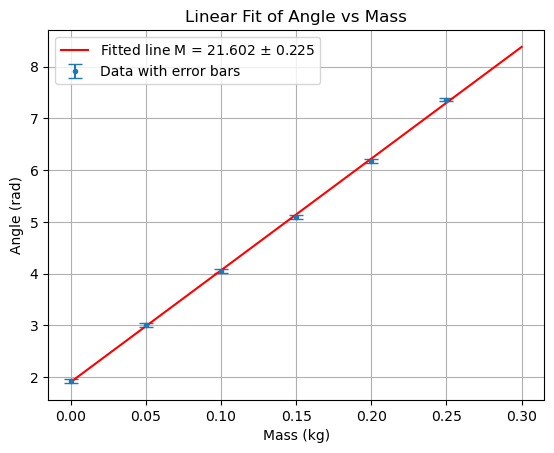

In [60]:
plt.errorbar(masses, angles, yerr=error_angles, fmt='.', label='Data with error bars', capsize=5)
x_fit = np.linspace(0, 0.300, 100)
y_fit = func(x_fit, *popt_D)
plt.plot(x_fit, y_fit, label=f'Fitted line M = {popt_D[0]:.3f} $\pm$ {np.sqrt(pcov_D[0, 0]):.3f}', color='red')

plt.xlabel('Mass (kg)')
plt.ylabel('Angle (rad)')
plt.title('Linear Fit of Angle vs Mass')
plt.legend()
plt.grid()



Richtmoment berechnen

In [78]:
M = unc.ufloat(popt_D[0], np.sqrt(pcov_D[0, 0]))
g = 9.81
r = unc.ufloat(5, 0.005) * 1e-2

D = g * r/M
print(f" D = {D:.3e}")

 D = (2.271+/-0.024)e-02


Aufgabe 2

In [ ]:
m_s = unc.ufloat(0.488, 0.001)
r
T_1 = unc.ufloat(1.21, 0.03)
T_2 = unc.ufloat(1.535, 0.025) 

D_period= 2* np.pi**2 * m_s * r**2 / (T_2**2 - T_1**2)
print(f" D über periodendauer = {D_period:.3e}")

 D über periodendauer = (2.699+/-0.320)e-02


A3 Trághetismomment unregelmäßige Platte

J_tisch

In [83]:
J_tisch = D * T_1**2 / (4 * np.pi**2)
print(f" J_tisch = {J_tisch:.3e}")

 J_tisch = (1.001+/-0.157)e-03


In [84]:
T_platte = unc.ufloat(2.355, 0.025)

J_ges = D * T_platte**2 / (4 * np.pi**2)
print(f" J_ges = {J_ges:.3e}")

J_platte = J_ges - J_tisch
print(f" J_platte = {J_platte:.3e}")

 J_ges = (3.792+/-0.456)e-03
 J_platte = (2.791+/-0.309)e-03


Aufgabe 4: trägheitsmomente/steiner

In [87]:
import uncertainties.unumpy as unp

In [88]:
T = np.array([47,1, 47.3, 48.0, 49.0, 51.8, 54.9])/20
err_T = np.full(T.shape, 0.5)/20

a = np.array([0, 5, 10, 20, 30, 40])*1e-3 # abstände
err_a = np.full(a.shape, 1)*1e-3

uncertainties_T = unp.uarray(T, err_T)
uncertainties_a = unp.uarray(a, err_a)